# k-Nearest Neighbors Classification

This notebook demonstrates the use of a k-Nearest Neighbors (KNN) classifier
for supervised binary classification on the Adult Census Income dataset.

The objective is to predict whether an individual's income exceeds $50K
based on demographic and employment-related features.

### Why k-Nearest Neighbors?

KNN is a non-parametric, instance-based learning algorithm that makes predictions
based on similarity to nearby data points in feature space.

Key characteristics:
- No explicit training phase beyond storing data
- Sensitive to feature scaling and distance metrics
- Performance depends heavily on the choice of *k*

Because the dataset contains both numeric and categorical variables,
proper preprocessing and scaling are critical for KNN to perform well.

Comments about Dataset given in Readme and in other algos written beforehand on the same census_income.csv dataset

In [1]:
import sys
from pathlib import Path
import pandas as pd

# allow importing from src
root = Path("../../../").resolve()
sys.path.append(str(root / "src"))

from rice_ml.supervised_learning.k_nearest_neighbors import (
    train_knn_model,
    evaluate_knn_model,
)

df = pd.read_csv("../../../datasets/census_income.csv")

model, X_train, X_test, y_train, y_test, cat_cols, num_cols = train_knn_model(
    df,
    target_col="income",
    n_neighbors=5,
)

metrics = evaluate_knn_model(model, X_test, y_test)

Accuracy: 0.8318149247620023
Confusion Matrix:
 [[6727  704]
 [ 939 1399]]
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      7431
        >50K       0.67      0.60      0.63      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.75      0.76      9769
weighted avg       0.83      0.83      0.83      9769



### Choice of k

In this experiment, `k = 5` is used as a balance between:
- Small k: lower bias, higher variance
- Large k: higher bias, smoother decision boundary

This value provides reasonable performance without excessive sensitivity
to noise.

### Results Interpretation

The k Nearest Neighbors classifier achieves an overall test accuracy of approximately 0.83, which is competitive with other baseline models on the Census Income dataset.

From the confusion matrix and classification report, we observe the following patterns:

>The model performs very well on the majority class (≤50K), with high recall.This indicates that most lower income individuals are correctly identified.

>Performance on the minority class (>50K) is weaker, particularly in recall. A significant number of higher income individuals are misclassified as ≤50K.

>Precision for the >50K class is moderate, suggesting that when the model predicts high income, it is often correct, but it fails to identify many true positives.

This behavior is consistent with the class imbalance present in the dataset and with the nature of KNN, which relies heavily on local neighborhood density. Because lower income samples dominate the feature space, neighborhoods tend to be biased toward the majority class.

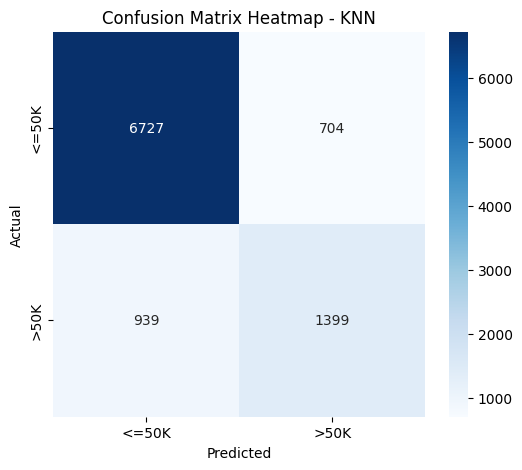

In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

preds = model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap - KNN")
plt.show()


### Confusion Matrix Interpretation

The confusion matrix highlights how the KNN classifier behaves across the two income classes.

>True Negatives (≤50K correctly classified) dominate the matrix, indicating that the model is highly effective at identifying lower income individuals.

>False Positives (>50K predicted when ≤50K is true) are relatively limited, showing that the model is conservative when assigning the higher income label.

>False Negatives (>50K misclassified as ≤50K) are more frequent, which reflects the difficulty of identifying higher income individuals in an imbalanced dataset.

>True Positives (>50K correctly classified) are present but fewer in number compared to the majority class outcomes.

This pattern suggests that the KNN model prioritizes precision over recall for the >50K class. In other words, when the model predicts a high income, it is often correct, but it fails to identify many true high income individuals.

From a practical perspective, this behavior is expected for KNN. Predictions are driven by local neighborhood density, and because ≤50K samples dominate the feature space, most neighborhoods are biased toward the majority class. As a result, minority class points are often outvoted by nearby majority class neighbors.

### Conclusion

The KNN classifier provides a solid baseline with strong performance on the majority class but exhibits clear limitations in recall for the minority class. While the model benefits from simplicity and interpretability, its reliance on distance based voting makes it sensitive to class imbalance.

These results reinforce the need for more expressive models when minority class identification is critical. In subsequent sections, tree based models are explored to address these limitations and improve overall generalization.

KNN remains valuable as a reference point, but it is not ideal as a final model for this task